In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

carpeta_salidas = "outputs"
ruta_consumos = "../data/raw/consumos_uptc.csv"

# Crear la carpeta outputs si no existe
if not os.path.exists(carpeta_salidas):
    os.makedirs(carpeta_salidas)
    print("Carpeta de salidas creada.")
else:
    print("Carpeta de salidas ya existe.")

# Cargar dataset principal
df_consumos = pd.read_csv(ruta_consumos)
df_consumos["timestamp"] = pd.to_datetime(df_consumos["timestamp"])

filas, columnas = df_consumos.shape
print(f"Dataset cargado. Filas: {filas} | Columnas: {columnas}")


✅ Carpeta outputs ya existe
Dataset cargado: (275387, 26)


🔍 ANÁLISIS DE VALORES NEGATIVOS

⚠️ Registros con energía negativa: 581
Porcentaje: 0.2110%

📊 Estadísticas de negativos:
count    581.000000
mean      -5.130574
std        5.419664
min      -38.987575
25%       -5.667000
50%       -3.871000
75%       -1.481000
max       -0.230000
Name: energia_total_kwh, dtype: float64

📍 Distribución por sede:
sede
Chiquinquirá    164
Duitama         155
Sogamoso        138
Tunja           124
Name: count, dtype: int64

🕐 Distribución por hora:
hora
0     21
1     20
2     25
3     27
4     18
5     22
6     23
7     19
8     20
9     24
10    22
11    28
12    15
13    29
14    29
15    35
16    27
17    23
18    22
19    30
20    23
21    17
22    28
23    34
Name: count, dtype: int64

📅 Distribución por año:
timestamp
2018    73
2019    73
2020    72
2021    71
2022    78
2023    79
2024    79
2025    56
Name: energia_total_kwh, dtype: int64


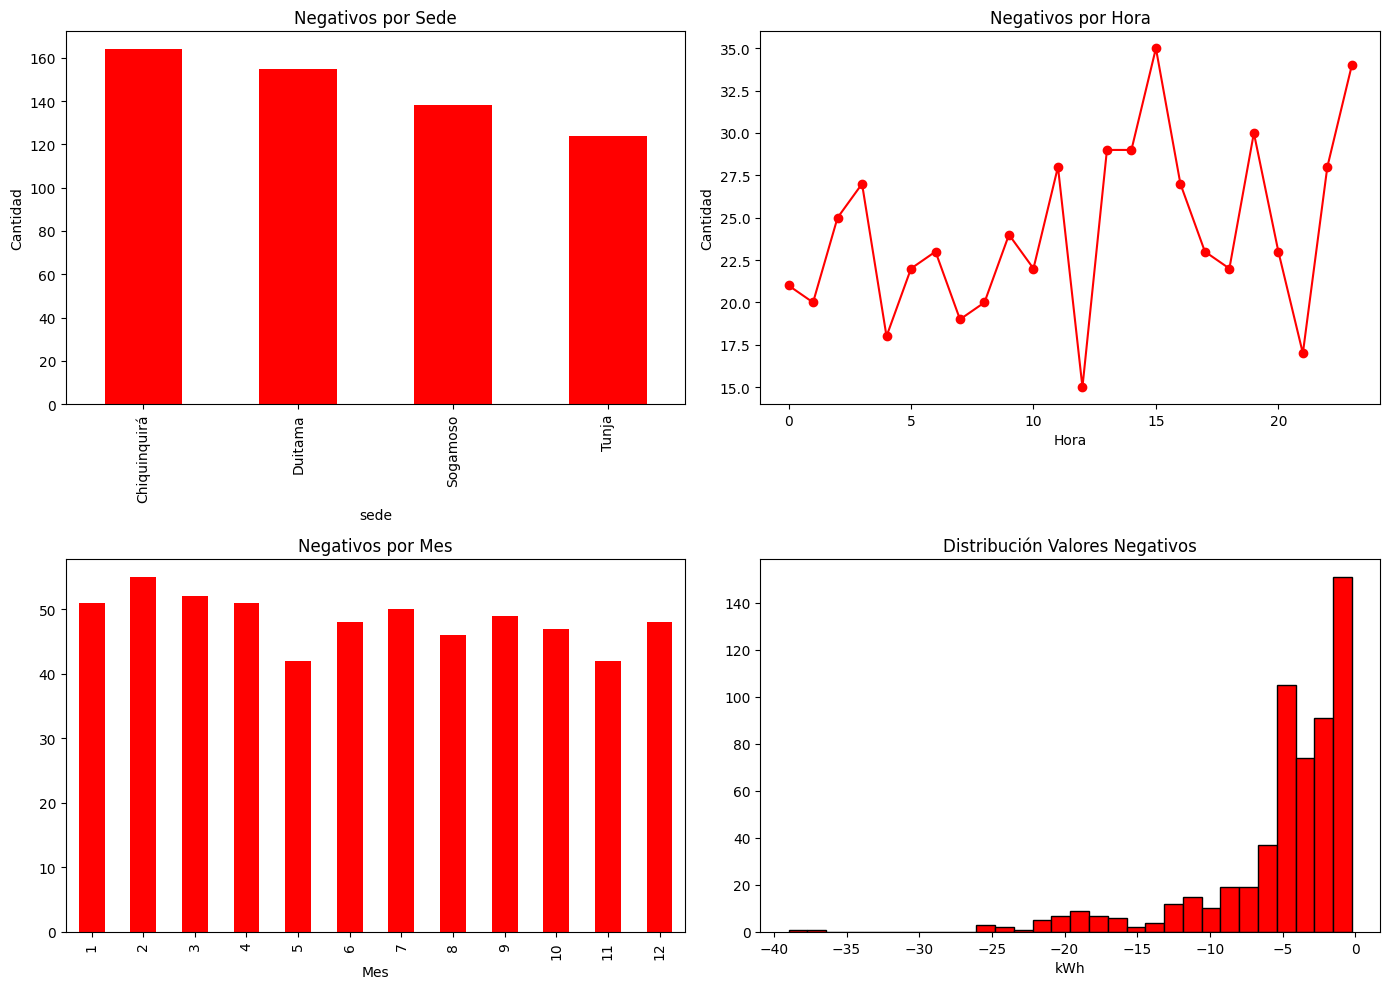


👁️ MUESTRA DE CASOS NEGATIVOS:
                timestamp          sede  hora  energia_total_kwh  \
180   2018-01-02 20:00:00         Tunja    20             -1.247   
497   2018-01-06 03:00:00         Tunja     3             -1.256   
2679  2018-01-28 18:00:00         Tunja    18             -1.478   
3307  2018-02-04 07:00:00      Sogamoso     7             -2.892   
3400  2018-02-05 06:00:00      Sogamoso     6             -3.036   
3473  2018-02-06 00:00:00         Tunja     0             -1.617   
4174  2018-02-13 07:00:00         Tunja     7             -7.579   
4542  2018-02-17 03:00:00         Tunja     3             -2.165   
5260  2018-02-24 15:00:00  Chiquinquirá    15             -0.980   
5291  2018-02-24 22:00:00         Tunja    22             -1.599   
5371  2018-02-25 18:00:00      Sogamoso    18             -3.074   
5503  2018-02-27 03:00:00       Duitama     3             -2.778   
6029  2018-03-04 14:00:00       Duitama    14             -2.645   
6031  2018-03-04

In [ ]:
# Revisar valores negativos

print("Analisis de valores negativos")

negativos_energia = df_consumos[df_consumos["energia_total_kwh"] < 0]
cantidad_negativos_energia = len(negativos_energia)
porcentaje_negativos_energia = (cantidad_negativos_energia / len(df_consumos)) * 100

print(f"Registros con energía negativa: {cantidad_negativos_energia}")
print(f"Porcentaje: {porcentaje_negativos_energia:.4f}%")

if cantidad_negativos_energia > 0:
    print("Estadísticas de energía negativa:")
    print(negativos_energia["energia_total_kwh"].describe())

    print("Distribución por sede:")
    print(negativos_energia["sede"].value_counts())

    print("Distribución por hora:")
    print(negativos_energia["hora"].value_counts().sort_index())

    # Conteo por año (con base en la columna timestamp del mismo subconjunto)
    conteo_por_anio = negativos_energia.groupby(negativos_energia["timestamp"].dt.year)["energia_total_kwh"].count()
    print("Distribución por año:")
    print(conteo_por_anio)

    # Gráficas
    fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

    # Negativos por sede
    negativos_energia["sede"].value_counts().plot(kind="bar", ax=ejes[0, 0])
    ejes[0, 0].set_title("Negativos por sede")
    ejes[0, 0].set_ylabel("Cantidad")

    # Negativos por hora
    negativos_energia["hora"].value_counts().sort_index().plot(kind="line", ax=ejes[0, 1], marker="o")
    ejes[0, 1].set_title("Negativos por hora")
    ejes[0, 1].set_xlabel("Hora")
    ejes[0, 1].set_ylabel("Cantidad")

    # Negativos por mes (si existe la columna "mes")
    if "mes" in negativos_energia.columns:
        negativos_energia["mes"].value_counts().sort_index().plot(kind="bar", ax=ejes[1, 0])
        ejes[1, 0].set_title("Negativos por mes")
        ejes[1, 0].set_xlabel("Mes")
    else:
        ejes[1, 0].text(0.5, 0.5, "No existe la columna 'mes'", ha="center", va="center")
        ejes[1, 0].set_title("Negativos por mes")

    # Distribución de valores negativos
    ejes[1, 1].hist(negativos_energia["energia_total_kwh"], bins=30, edgecolor="black")
    ejes[1, 1].set_title("Distribución de valores negativos")
    ejes[1, 1].set_xlabel("kWh")

    plt.tight_layout()

    ruta_grafico_negativos = os.path.join(carpeta_salidas, "negativos_analisis.png")
    plt.savefig(ruta_grafico_negativos, dpi=150)
    plt.show()

    print("Muestra de casos con energía negativa:")
    columnas_muestra = [
        "timestamp",
        "sede",
        "hora",
        "energia_total_kwh",
        "energia_comedor_kwh",
        "energia_salones_kwh",
        "energia_laboratorios_kwh",
    ]
    columnas_existentes = [col for col in columnas_muestra if col in negativos_energia.columns]
    print(negativos_energia[columnas_existentes].head(20))
else:
    print("No hay valores negativos en energía total.")

negativos_co2 = df_consumos[df_consumos["co2_kg"] < 0]
cantidad_negativos_co2 = len(negativos_co2)
porcentaje_negativos_co2 = (cantidad_negativos_co2 / len(df_consumos)) * 100

print(f"Registros con CO2 negativo: {cantidad_negativos_co2}")
print(f"Porcentaje: {porcentaje_negativos_co2:.4f}%")


In [ ]:
# Analisis de outliers extremos (percentiles)

print("Analisis de outliers extremos en energia_total_kwh")

percentil_99 = df_consumos["energia_total_kwh"].quantile(0.99)
percentil_95 = df_consumos["energia_total_kwh"].quantile(0.95)
percentil_1 = df_consumos["energia_total_kwh"].quantile(0.01)

outliers_superiores = df_consumos[df_consumos["energia_total_kwh"] > percentil_99]
outliers_inferiores = df_consumos[df_consumos["energia_total_kwh"] < percentil_1]

porcentaje_superiores = (len(outliers_superiores) / len(df_consumos)) * 100
porcentaje_inferiores = (len(outliers_inferiores) / len(df_consumos)) * 100

print(f"Límite inferior (P1): {percentil_1:.2f} kWh")
print(f"Límite superior (P99): {percentil_99:.2f} kWh")
print(f"Límite (P95): {percentil_95:.2f} kWh")

print(f"Outliers superiores (>P99): {len(outliers_superiores)} ({porcentaje_superiores:.2f}%)")
print(f"Outliers inferiores (<P1): {len(outliers_inferiores)} ({porcentaje_inferiores:.2f}%)")

print("Top 20 valores más altos:")
columnas_top_20 = ["timestamp", "sede", "hora", "dia_nombre", "energia_total_kwh", "periodo_academico"]
columnas_top_20_existentes = [col for col in columnas_top_20 if col in df_consumos.columns]
top_20 = df_consumos.nlargest(20, "energia_total_kwh")[columnas_top_20_existentes]
print(top_20)

print("Verificación de coherencia (top 20):")
columnas_sectores = [
    "energia_comedor_kwh",
    "energia_salones_kwh",
    "energia_laboratorios_kwh",
    "energia_auditorios_kwh",
    "energia_oficinas_kwh",
]

top_20_completo = df_consumos.nlargest(20, "energia_total_kwh").copy()
sectores_existentes = [col for col in columnas_sectores if col in top_20_completo.columns]

top_20_completo["suma_sectores"] = top_20_completo[sectores_existentes].sum(axis=1)
top_20_completo["diferencia"] = top_20_completo["energia_total_kwh"] - top_20_completo["suma_sectores"]
top_20_completo["diferencia_pct"] = (top_20_completo["diferencia"] / top_20_completo["energia_total_kwh"]) * 100

columnas_reporte = ["timestamp", "sede", "energia_total_kwh", "suma_sectores", "diferencia", "diferencia_pct"]
print(top_20_completo[columnas_reporte])

media_diferencia = top_20_completo["diferencia"].mean()
media_diferencia_pct = top_20_completo["diferencia_pct"].mean()

print(f"Media diferencia: {media_diferencia:.2f} kWh")
print(f"Media diferencia %: {media_diferencia_pct:.2f}%")


🔍 ANÁLISIS DE OUTLIERS EXTREMOS

📊 Límite inferior (Q1%): 0.26 kWh
📊 Límite superior (Q99%): 23.91 kWh
📊 Límite Q95%: 18.05 kWh

⚠️ Outliers superiores (>Q99): 2753 (1.00%)
⚠️ Outliers inferiores (<Q1): 2734 (0.99%)

🔺 TOP 20 VALORES MÁS ALTOS:
                 timestamp      sede  hora dia_nombre  energia_total_kwh  \
43363  2019-03-27 08:00:00   Duitama     8  Miércoles         190.455481   
200331 2023-09-12 11:00:00   Duitama    11     Martes         189.293906   
269657 2025-09-01 11:00:00  Sogamoso    11      Lunes         187.362699   
237002 2024-09-27 08:00:00   Duitama     8    Viernes         183.635684   
191455 2023-06-12 07:00:00   Duitama     7      Lunes         181.775739   
45491  2019-04-18 10:00:00   Duitama    10     Jueves         178.647327   
49338  2019-05-28 10:00:00   Duitama    10     Martes         177.891947   
223244 2024-05-07 10:00:00   Duitama    10     Martes         173.010483   
236727 2024-09-24 11:00:00  Sogamoso    11     Martes         171.67787

🔍 COHERENCIA GLOBAL: TOTAL vs SUMA SECTORES

📊 ESTADÍSTICAS DE COHERENCIA:
         diferencia  diferencia_abs  diferencia_pct
count  2.753870e+05   275387.000000   275387.000000
mean   1.068810e-01        0.231524        1.762284
std    3.275658e+00        3.269213       14.711649
min   -5.183830e+01        0.000000        0.000000
25%   -2.000000e-04        0.000100        0.002657
50%    2.220446e-16        0.000300        0.007583
75%    3.000000e-04        0.000400        0.021333
max    1.646681e+02      164.668081      342.248947

⚠️ Registros con >10% diferencia: 4676 (1.70%)
💾 Gráfico guardado: outputs/coherencia_sectores.png


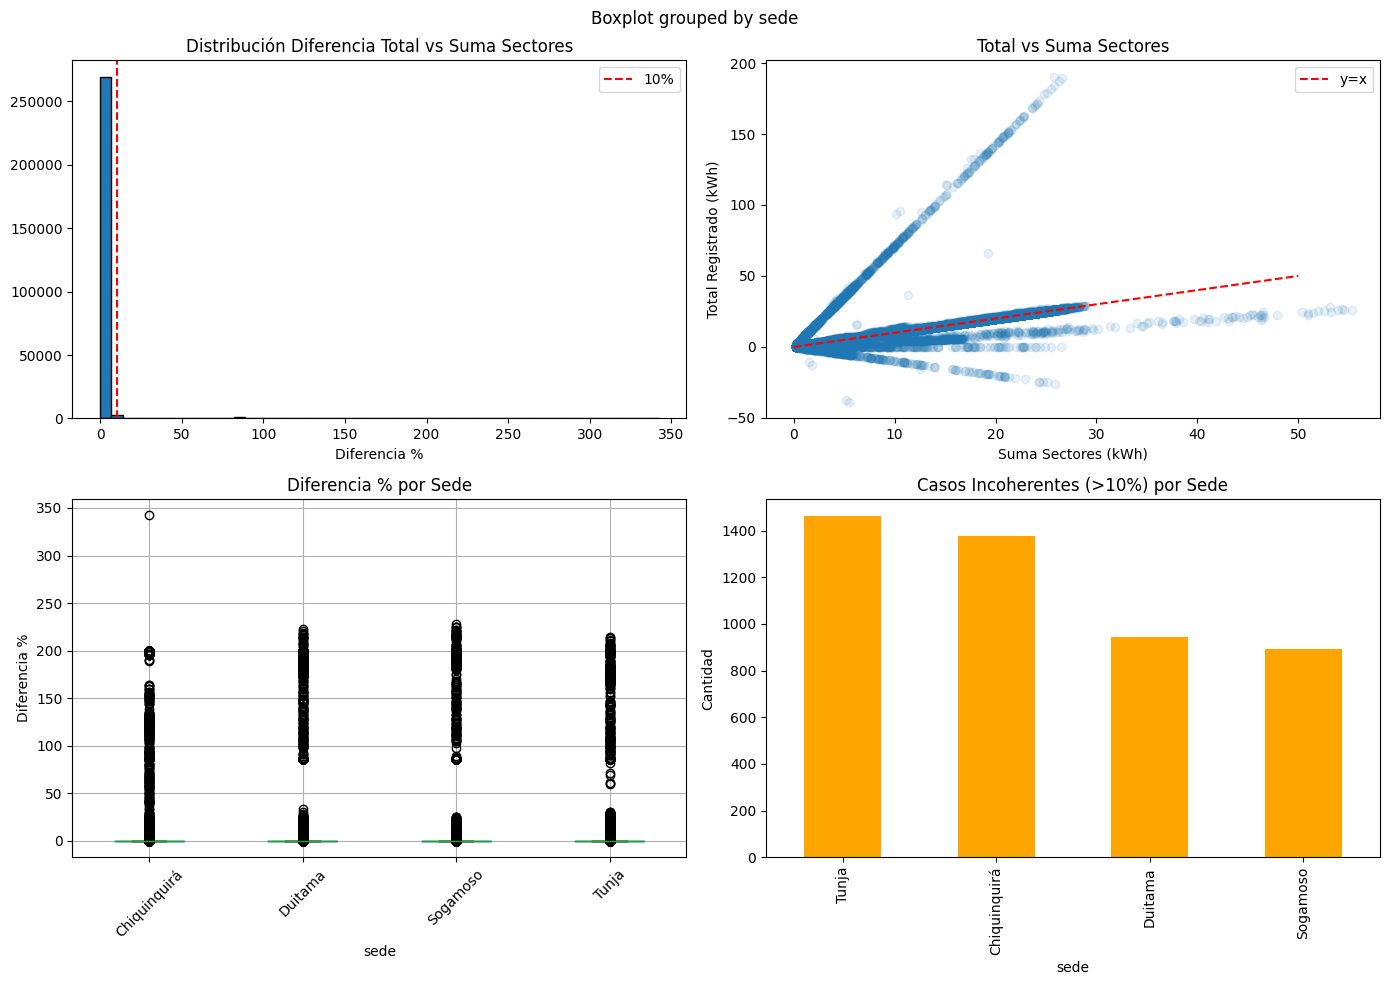

In [ ]:
# Coherencia global (total vs suma de sectores)
print("Coherencia global: energia_total_kwh vs suma de sectores")

df_coherencia = df_consumos.copy()

columnas_sectores = [
    "energia_comedor_kwh",
    "energia_salones_kwh",
    "energia_laboratorios_kwh",
    "energia_auditorios_kwh",
    "energia_oficinas_kwh",
]
sectores_existentes = [col for col in columnas_sectores if col in df_coherencia.columns]

# Para este cálculo, tratamos NaN como 0 (solo para comparar con el total)
df_coherencia[sectores_existentes] = df_coherencia[sectores_existentes].fillna(0)

df_coherencia["suma_sectores"] = df_coherencia[sectores_existentes].sum(axis=1)
df_coherencia["diferencia"] = df_coherencia["energia_total_kwh"] - df_coherencia["suma_sectores"]
df_coherencia["diferencia_abs"] = df_coherencia["diferencia"].abs()

# Evitar división por cero
df_coherencia["diferencia_pct"] = np.where(
    df_coherencia["energia_total_kwh"] != 0,
    (df_coherencia["diferencia_abs"] / df_coherencia["energia_total_kwh"].abs()) * 100,
    0,
)

# Limpiar valores infinitos si llegaran a aparecer
df_coherencia["diferencia_pct"] = df_coherencia["diferencia_pct"].replace([np.inf, -np.inf], np.nan)

print("Estadísticas de coherencia:")
print(df_coherencia[["diferencia", "diferencia_abs", "diferencia_pct"]].describe())

incoherentes = df_coherencia[df_coherencia["diferencia_pct"] > 10]
porcentaje_incoherentes = (len(incoherentes) / len(df_consumos)) * 100

print(f"Registros con más del 10% de diferencia: {len(incoherentes)} ({porcentaje_incoherentes:.2f}%)")

# Gráficas
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma diferencia %
diferencia_pct_limpia = df_coherencia["diferencia_pct"].dropna()
diferencia_pct_limpia = diferencia_pct_limpia[np.isfinite(diferencia_pct_limpia)]

ejes[0, 0].hist(diferencia_pct_limpia, bins=50, edgecolor="black")
ejes[0, 0].set_xlabel("Diferencia (%)")
ejes[0, 0].set_title("Diferencia total vs suma de sectores")
ejes[0, 0].axvline(10, linestyle="--", label="10%")
ejes[0, 0].legend()

# Scatter total vs suma de sectores
ejes[0, 1].scatter(df_coherencia["suma_sectores"], df_coherencia["energia_total_kwh"], alpha=0.1)
ejes[0, 1].set_xlabel("Suma sectores (kWh)")
ejes[0, 1].set_ylabel("Total registrado (kWh)")
ejes[0, 1].set_title("Total vs suma de sectores")

# Línea de referencia y=x (con rango simple basado en el máximo observado)
maximo_referencia = max(df_coherencia["suma_sectores"].max(), df_coherencia["energia_total_kwh"].max())
ejes[0, 1].plot([0, maximo_referencia], [0, maximo_referencia], linestyle="--", label="y = x")
ejes[0, 1].legend()

# Boxplot diferencia % por sede
df_coherencia.boxplot(column="diferencia_pct", by="sede", ax=ejes[1, 0])
ejes[1, 0].set_title("Diferencia (%) por sede")
ejes[1, 0].set_ylabel("Diferencia (%)")
plt.sca(ejes[1, 0])
plt.xticks(rotation=45)

# Casos incoherentes por sede
if len(incoherentes) > 0:
    incoherentes["sede"].value_counts().plot(kind="bar", ax=ejes[1, 1])
    ejes[1, 1].set_title("Casos incoherentes (>10%) por sede")
    ejes[1, 1].set_ylabel("Cantidad")
else:
    ejes[1, 1].text(0.5, 0.5, "No se encontraron casos incoherentes", ha="center", va="center")
    ejes[1, 1].set_title("Casos incoherentes (>10%) por sede")

plt.tight_layout()

ruta_grafico_coherencia = os.path.join(carpeta_salidas, "coherencia_sectores.png")
plt.savefig(ruta_grafico_coherencia, dpi=150)
plt.show()


🔍 PATRONES POR SEDE Y SECTOR

📊 CONSUMO PROMEDIO POR SEDE:
              energia_comedor_kwh  energia_salones_kwh  \
sede                                                     
Chiquinquirá             0.135133             0.702896   
Duitama                  0.412302             1.369827   
Sogamoso                 0.406680             1.256407   
Tunja                    0.229771             0.571601   

              energia_laboratorios_kwh  energia_auditorios_kwh  \
sede                                                             
Chiquinquirá                  0.733502                0.076438   
Duitama                       3.583995                0.130572   
Sogamoso                      3.848556                0.111417   
Tunja                         1.539954                0.069804   

              energia_oficinas_kwh  
sede                                
Chiquinquirá              0.775276  
Duitama                   1.605315  
Sogamoso                  1.581371  
Tunja     

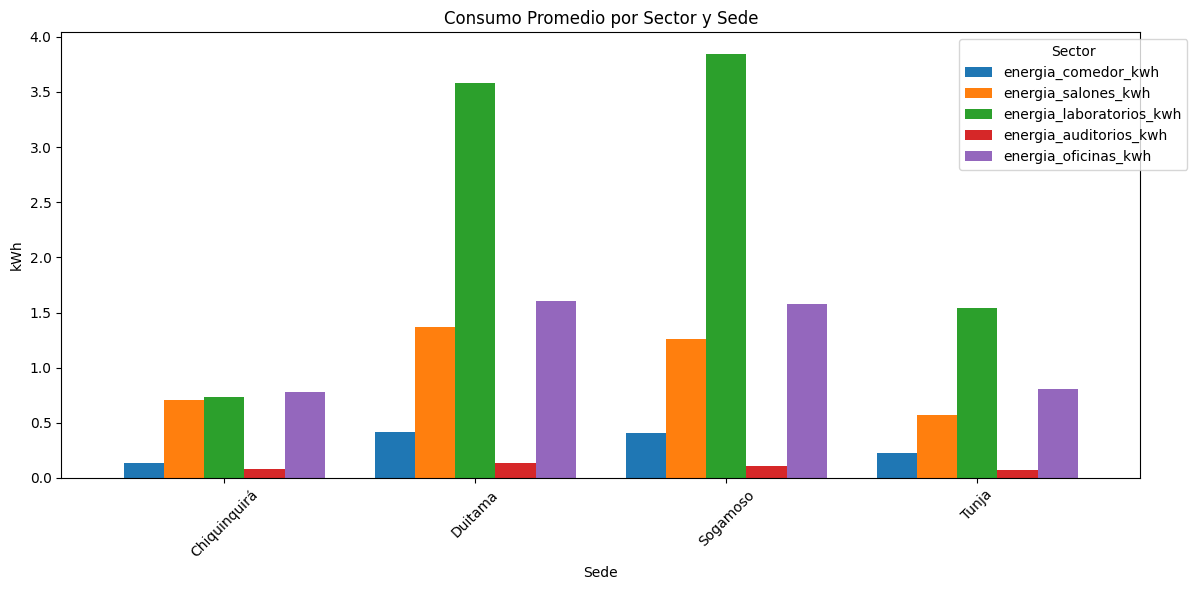


📊 PROPORCIÓN % POR SECTOR:
              energia_comedor_kwh  energia_salones_kwh  \
sede                                                     
Chiquinquirá             5.576534            29.006393   
Duitama                  5.805420            19.287877   
Sogamoso                 5.644859            17.439363   
Tunja                    7.147381            17.780536   

              energia_laboratorios_kwh  energia_auditorios_kwh  \
sede                                                             
Chiquinquirá                 30.269414                3.154363   
Duitama                      50.464517                1.838524   
Sogamoso                     53.419292                1.546506   
Tunja                        47.902634                2.171363   

              energia_oficinas_kwh  
sede                                
Chiquinquirá             31.993296  
Duitama                  22.603663  
Sogamoso                 21.949979  
Tunja                    24.998086  
💾 Gr

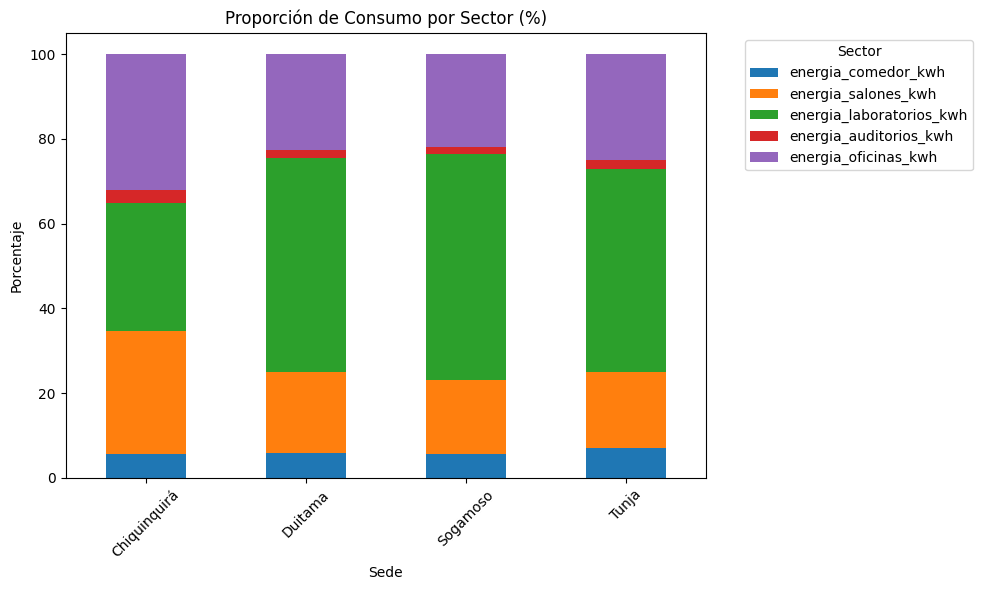

In [ ]:
# Patrones por sede y sector
print("Patrones por sede y sector")

columnas_sectores = [
    "energia_comedor_kwh",
    "energia_salones_kwh",
    "energia_laboratorios_kwh",
    "energia_auditorios_kwh",
    "energia_oficinas_kwh",
]

sectores_existentes = [col for col in columnas_sectores if col in df_consumos.columns]

consumo_promedio_sede_sector = df_consumos.groupby("sede")[sectores_existentes].mean()
print("Consumo promedio por sede:")
print(consumo_promedio_sede_sector)

# Gráfico: consumo promedio por sector y sede
ax = consumo_promedio_sede_sector.plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_title("Consumo promedio por sector y sede")
ax.set_ylabel("kWh")
ax.set_xlabel("Sede")
plt.xticks(rotation=45)
plt.legend(title="Sector", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

ruta_grafico_consumo = os.path.join(carpeta_salidas, "consumo_sede_sector.png")
plt.savefig(ruta_grafico_consumo, dpi=150)
plt.show()

# Proporción porcentual por sector en cada sede
proporcion_sector = consumo_promedio_sede_sector.div(consumo_promedio_sede_sector.sum(axis=1), axis=0) * 100
print("Proporción (%) por sector:")
print(proporcion_sector)

ax = proporcion_sector.plot(kind="bar", stacked=True, figsize=(10, 6))
ax.set_title("Proporción de consumo por sector (%)")
ax.set_ylabel("Porcentaje")
ax.set_xlabel("Sede")
plt.xticks(rotation=45)
plt.legend(title="Sector", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

ruta_grafico_proporcion = os.path.join(carpeta_salidas, "proporcion_sede_sector.png")
plt.savefig(ruta_grafico_proporcion, dpi=150)
plt.show()


🔍 PATRONES TEMPORALES AVANZADOS

📚 CONSUMO POR PERÍODO ACADÉMICO:
                       mean  median       std   count
periodo_academico                                    
semestre_2         5.807337  4.1520  6.884367   79522
semestre_1         5.714211  4.0840  6.739226  115325
Semestre_1         5.243087  3.5955  6.595850     710
semestre1          5.147576  3.4920  8.712759     699
SEMESTRE_1         5.101333  3.5435  6.003756     726
vacaciones         5.100443  3.4280  5.689311     654
vacaciones_mitad   4.003228  3.0515  3.741941   51114
vacaciones_fin     2.213823  1.7220  1.753599   26637

📅 FIN DE SEMANA VS ENTRE SEMANA:
                   mean  median       std
es_fin_semana                            
False          5.830455   4.066  6.788966
True           3.197173   2.253  3.271584

💡 Diferencia: 2.63 kWh
% Reducción fin de semana: 45.16%

📝 SEMANAS ESPECIALES:
Parciales:
es_semana_parciales
False    5.040773
True     5.484494
Name: energia_total_kwh, dtype: float64

Fin

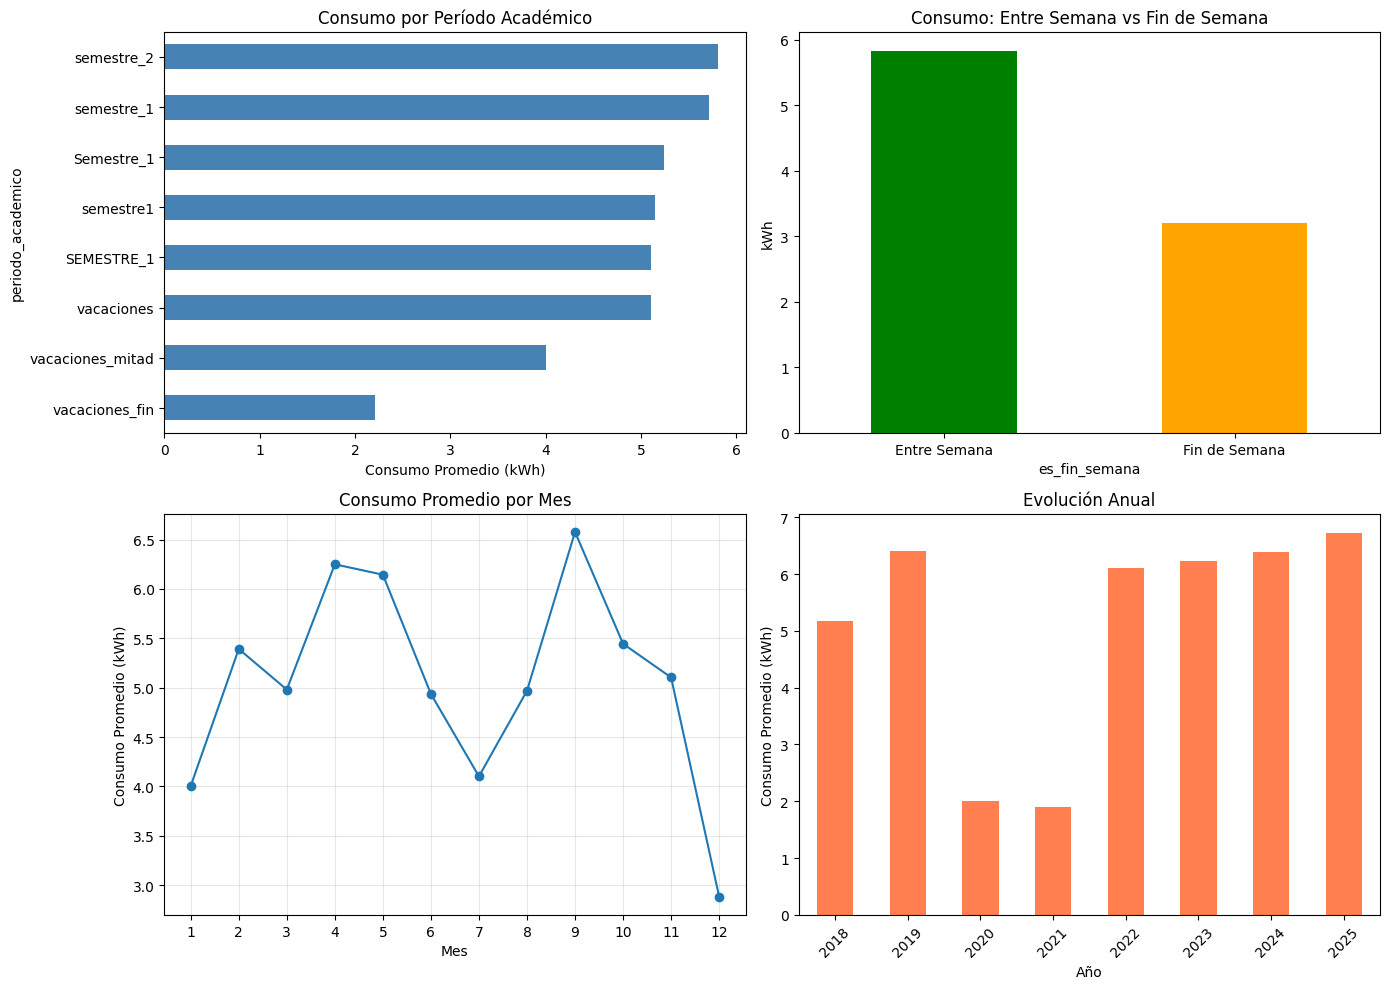

In [ ]:
# Patrones temporales (por periodo, fin de semana, mes y año)
print("Patrones temporales")

# Consumo por período académico
if "periodo_academico" in df_consumos.columns:
    consumo_por_periodo = df_consumos.groupby("periodo_academico")["energia_total_kwh"].agg(["mean", "median", "std", "count"])
    print("Consumo por período académico:")
    print(consumo_por_periodo.sort_values("mean", ascending=False))
else:
    consumo_por_periodo = None
    print("No existe la columna 'periodo_academico'.")

# Fin de semana vs entre semana
if "es_fin_semana" in df_consumos.columns:
    consumo_fin_semana = df_consumos.groupby("es_fin_semana")["energia_total_kwh"].agg(["mean", "median", "std"])
    print("Fin de semana vs entre semana:")
    print(consumo_fin_semana)

    if False in consumo_fin_semana.index and True in consumo_fin_semana.index:
        diferencia_kwh = consumo_fin_semana.loc[False, "mean"] - consumo_fin_semana.loc[True, "mean"]
        reduccion_pct = (1 - (consumo_fin_semana.loc[True, "mean"] / consumo_fin_semana.loc[False, "mean"])) * 100
        print(f"Diferencia (entre semana - fin de semana): {diferencia_kwh:.2f} kWh")
        print(f"Reducción fin de semana: {reduccion_pct:.2f}%")
else:
    consumo_fin_semana = None
    print("No existe la columna 'es_fin_semana'.")

# Semanas especiales
if "es_semana_parciales" in df_consumos.columns:
    promedio_parciales = df_consumos.groupby("es_semana_parciales")["energia_total_kwh"].mean()
    print("Promedio en semana de parciales:")
    print(promedio_parciales)

if "es_semana_finales" in df_consumos.columns:
    promedio_finales = df_consumos.groupby("es_semana_finales")["energia_total_kwh"].mean()
    print("Promedio en semana de finales:")
    print(promedio_finales)

# Gráficas
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

# Por período académico
if consumo_por_periodo is not None:
    consumo_por_periodo["mean"].sort_values().plot(kind="barh", ax=ejes[0, 0])
    ejes[0, 0].set_xlabel("Consumo promedio (kWh)")
    ejes[0, 0].set_title("Consumo por período académico")
else:
    ejes[0, 0].text(0.5, 0.5, "Sin datos de período académico", ha="center", va="center")
    ejes[0, 0].set_title("Consumo por período académico")

# Fin de semana
if consumo_fin_semana is not None:
    consumo_fin_semana["mean"].plot(kind="bar", ax=ejes[0, 1])
    ejes[0, 1].set_title("Entre semana vs fin de semana")
    ejes[0, 1].set_ylabel("kWh")
    ejes[0, 1].tick_params(axis="x", rotation=0)
else:
    ejes[0, 1].text(0.5, 0.5, "Sin datos de fin de semana", ha="center", va="center")
    ejes[0, 1].set_title("Entre semana vs fin de semana")

# Por mes
if "mes" in df_consumos.columns:
    df_consumos.groupby("mes")["energia_total_kwh"].mean().plot(kind="line", marker="o", ax=ejes[1, 0])
    ejes[1, 0].set_xlabel("Mes")
    ejes[1, 0].set_ylabel("Consumo promedio (kWh)")
    ejes[1, 0].set_title("Consumo promedio por mes")
    ejes[1, 0].set_xticks(range(1, 13))
else:
    ejes[1, 0].text(0.5, 0.5, "No existe la columna 'mes'", ha="center", va="center")
    ejes[1, 0].set_title("Consumo promedio por mes")

# Por año
df_consumos.groupby(df_consumos["timestamp"].dt.year)["energia_total_kwh"].mean().plot(kind="bar", ax=ejes[1, 1])
ejes[1, 1].set_xlabel("Año")
ejes[1, 1].set_ylabel("Consumo promedio (kWh)")
ejes[1, 1].set_title("Evolución anual")
ejes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()

ruta_grafico_temporal = os.path.join(carpeta_salidas, "patrones_temporales.png")
plt.savefig(ruta_grafico_temporal, dpi=150)
plt.show()


In [ ]:
# Resumen de hallazgos y estrategia de limpieza
print("Resumen de hallazgos y estrategia de limpieza")

cantidad_negativos_energia = len(df_consumos[df_consumos["energia_total_kwh"] < 0])
cantidad_negativos_co2 = len(df_consumos[df_consumos["co2_kg"] < 0])

limite_outliers_99 = df_consumos["energia_total_kwh"].quantile(0.99)
cantidad_outliers_99 = len(df_consumos[df_consumos["energia_total_kwh"] > limite_outliers_99])

# df_coherencia - Coherencia global (total vs suma de sectores)
cantidad_incoherencias = 0
if "df_coherencia" in globals() and "diferencia_pct" in df_coherencia.columns:
    cantidad_incoherencias = len(df_coherencia[df_coherencia["diferencia_pct"] > 10])

nulos_ocupacion = 0
if "ocupacion_pct" in df_consumos.columns:
    nulos_ocupacion = df_consumos["ocupacion_pct"].isnull().sum()

print("Problemas:")
print(f"Valores negativos de energía: {cantidad_negativos_energia}")
print(f"Valores negativos de CO2: {cantidad_negativos_co2}")
print(f"Outliers extremos (> P99): {cantidad_outliers_99}")
print(f"Incoherencias en sectores (> 10%): {cantidad_incoherencias}")
print(f"Valores nulos en ocupación: {nulos_ocupacion}")


📋 RESUMEN DE HALLAZGOS Y ESTRATEGIA DE LIMPIEZA

🚨 PROBLEMAS IDENTIFICADOS:
1. Valores negativos energía: 581
2. Valores negativos CO2: 543
3. Outliers extremos (>Q99): 2753
4. Incoherencias sectores (>10%): 4676
5. Missing values ocupación: 32766 (11.9%)

✅ ESTRATEGIA PROPUESTA:
1. Negativos: Convertir a valor absoluto O eliminar (decidir en equipo)
2. Outliers: Filtrar percentil 0.5% - 99.5%
3. Incoherencias: Recalcular total como suma de sectores si diferencia >15%
4. Missing: Imputar con medias por grupo (sede, hora, día)
5. CO2: Recalcular desde energía (factor 0.45 kg/kWh)

🎯 PREGUNTAS PARA EL EQUIPO:
- ¿Eliminamos negativos o convertimos a absoluto?
- ¿Qué percentil usar para outliers? (99%? 99.5%?)
- ¿Recalcular total o eliminar incoherentes?
